## FastSparse: 

In [1]:
from src.run_app import *
from src.prepare_gam import *
from src.utils import *
import pickle as pkl

header dimension 142
lamb0:0.001, lamb2:0.5, acc:0.6709135659475894, auc:0.728105294647142, supp_size:15
pair before removing {'age': [22.0, 27.0, 32.0, 33.0, 36.0], 'juvenile_crimes': [0.0], 'priors_count': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]}
k, v age [22.0, 27.0, 32.0, 33.0, 36.0, 96]
k, v juvenile_crimes [0.0, 20]
k, v priors_count [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 38]
pair after removing {'age': [22.0, 27.0, 32.0, 33.0, 36.0, 96], 'juvenile_crimes': [0.0, 20], 'priors_count': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 38]}
v_count: [0, 6, 2, 9]
[ 0  6  8 17]
age 0 0
age 1 1
age 2 2
age 3 3
age 4 4
age 5 5
juvenile_crimes 0 6
juvenile_crimes 1 7
priors_count 0 8
priors_count 1 9
priors_count 2 10
priors_count 3 11
priors_count 4 12
priors_count 5 13
priors_count 6 14
priors_count 7 15
priors_count 8 16
True
True
True
(18,) hi
(18,) hi2
(6907, 18) (18,) (6907, 18) (18,)
objective: 1.0675942570197012 objective in LR 1.0675942570197012
m:1.01, log objective:1.067594257019701

<Figure size 550x400 with 0 Axes>

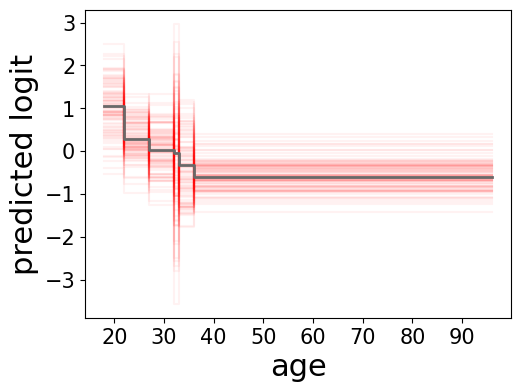

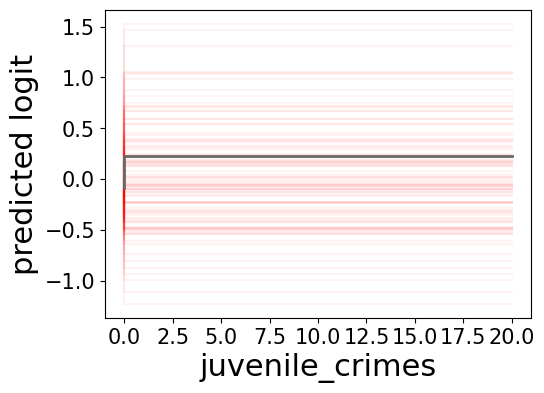

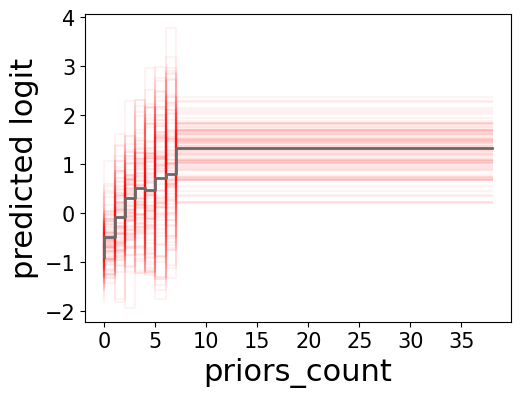

In [2]:
dname = "compas"
l0 = 0.001
l2 = 0.5
m = 1.01

betas_fastSparse = prepare_sparse_gam(dname, l0, l2, m)
filepath = "{}_{}_{}_{}.p".format(dname, l0, l2, m)
w_samples = get_models_from_rset(filepath, n_samples=100, plot_shape=True, sample_from_surface=False)

In [3]:
# load the dataset
dataset_name = 'compas'
path = 'datasets/{}.csv'.format(dataset_name)
dataset = pd.read_csv(path)
dataset.iloc[:, -1][dataset.iloc[:, -1] == 0] = -1
X, y = dataset.iloc[:, :-1], dataset.iloc[:, -1]

X_one_hot, count = one_hot_encoding(X, one_hot=True)
y = pd.DataFrame(y)  # {0,1}

header = list(X_one_hot.columns)
header = pd.Index(["intercept"] + header)
header = header.astype("object")

# add a column of one to X_orig and make y in {1,-1}
X_one_hot, y = utils.get_X_y(X_one_hot, y)
y = y[:, -1]

print("header dimension", len(header), flush=True)
print(X_one_hot.shape, y.shape)

header dimension 142
(6907, 142) (6907,)


In [4]:
# load model
X_fastsparse = pkl.load(open(betas_fastSparse, 'rb'))['X']
mean_loss = 0
for i in range(len(w_samples)):
    # make predictions
    w0 = w_samples[i, :]
    logits = X_fastsparse @ w0
    y_pred = np.exp(logits)/(1+np.exp(logits))
    y_pred[y_pred > 0.5] = 1
    y_pred[y_pred <= 0.5] = -1
    # compute loss
    mean_loss += (y != y_pred).mean()
print("mean loss: {}".format(mean_loss / len(w_samples)))

mean loss: 0.37443607933980033


## FasterRisk

In [5]:
from FasterRisk.src.fasterrisk import fasterrisk

# using extended get sparse diverse pool
rs = fasterrisk.RiskScoreOptimizer(X_one_hot, y, k=10, lb=-100, ub=100, gap_tolerance=0.003, select_top_m=100)
rs.optimize(generate_non_integer_solution=True, test=True, swaps=2)
beta0, betas = rs.sparseDiversePool_beta0, rs.sparseDiversePool_betas

# rs = fasterrisk.RiskScoreOptimizer(X_one_hot, y, k=10, lb=-100, ub=100, gap_tolerance=0.002, select_top_m=100)
# rs.optimize(generate_non_integer_solution=True, test=True, swaps=1)
# beta0, betas = rs.sparseDiversePool_beta0, rs.sparseDiversePool_betas

[  4   5   6   7   8  89 103 104 105 106]
swaps is 1: [8], [12], [4258.19571245 4258.95913992 4258.95913992 4259.25764273 4260.40229772
 4260.40229772], [451 454 453 452 455 456]
swaps is 1: [8], [9], [4258.19571245 4261.08189117 4261.08189117 4261.61835805], [450 454 453 452]
swaps is 1: [8], [41], [4259.25764231 4260.39716901 4260.39716901 4261.61835722], [450 454 453 452]
swaps is 1: [8], [1], [4258.95913968 4260.3971693  4261.08189069], [450 452 453]
swaps is 1: [8], [2], [4258.95913968 4260.3971693  4261.08189069], [450 452 453]
swaps is 1: [8], [107], [], []
swaps is 1: [8], [108], [], []
swaps is 1: [8], [140], [4260.40229727 4262.21582547], [400 402]
swaps is 1: [8], [141], [4260.40229727 4262.21582547], [400 402]
swaps is 1: [8], [25], [], []
swaps is 1: [8], [38], [], []
swaps is 1: [8], [10], [], []
swaps is 1: [8], [42], [], []
swaps is 1: [8], [125], [], []
swaps is 1: [8], [14], [], []
swaps is 1: [8], [46], [], []
swaps is 1: [8], [120], [], []
swaps is 1: [8], [113], []

In [6]:
mean_loss = 0
for i in range(len(betas)):
    wi = betas[i, :]
    intercepti = beta0[i]
    logit = X_one_hot @ wi + intercepti
    y_pred = np.exp(logit) / (1 + np.exp(logit))
    y_pred = np.where(y_pred > 0.5, 1, -1)
    mean_loss += (y != y_pred).mean()
    print(np.nonzero(wi)[0])
    print((y != y_pred).mean())
print(mean_loss / len(betas))

[  4   5   6   7  41  89 103 104 105 141]
0.33082380194006084
[  4   5   6   7  41  89 103 104 105 140]
0.33082380194006084
[  4   5   6   7  25  41  89 103 104 105]
0.3306790212827566
[  4   5   6   7  12  89 103 104 105 141]
0.33241638917040683
[  4   5   6   7  12  89 103 104 105 140]
0.33241638917040683
[  4   5   6   7  12  89 103 104 105 126]
0.3318372665411901
[  4   5   6   7  12  89 103 104 105 125]
0.3318372665411901
[  4   5   6   7  12  89 103 104 105 120]
0.3318372665411901
[  4   5   6   7  12  89 103 104 105 113]
0.3318372665411901
[  4   5   6   7  12  89 103 104 105 108]
0.3318372665411901
[  4   5   6   7  12  89 103 104 105 107]
0.3318372665411901
[  4   5   6   7  12  56  89 103 104 105]
0.33140292456927756
[  4   5   6   7  12  42  89 103 104 105]
0.33140292456927756
[  4   5   6   7  12  41  89 103 104 105]
0.3300998986535399
[  4   5   6   7  12  38  89 103 104 105]
0.3316924858838859
[  4   5   6   7  12  25  89 103 104 105]
0.33212682785579845
[  4   5   6   7 

In [7]:
# GAMS identify artefacts in the data -> Zack
# Regularization based on data distribution?
# Constraint for hard penalty (l0) -> evaluate it on soft penalty (l2)
# Histogram of support sets (overlapping)
# Domain knowledge -> support sets
# modify beam search to only include support sets that are sufficiently different
# (where a diversity parameter is specified by the user)
print(betas.shape)

(33, 142)


100%|██████████| 33/33 [00:00<00:00, 494.98it/s]
/var/folders/7g/zkyqkq094znbhbyfb390fvsm0000gn/T/ipykernel_2594/4225544202.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


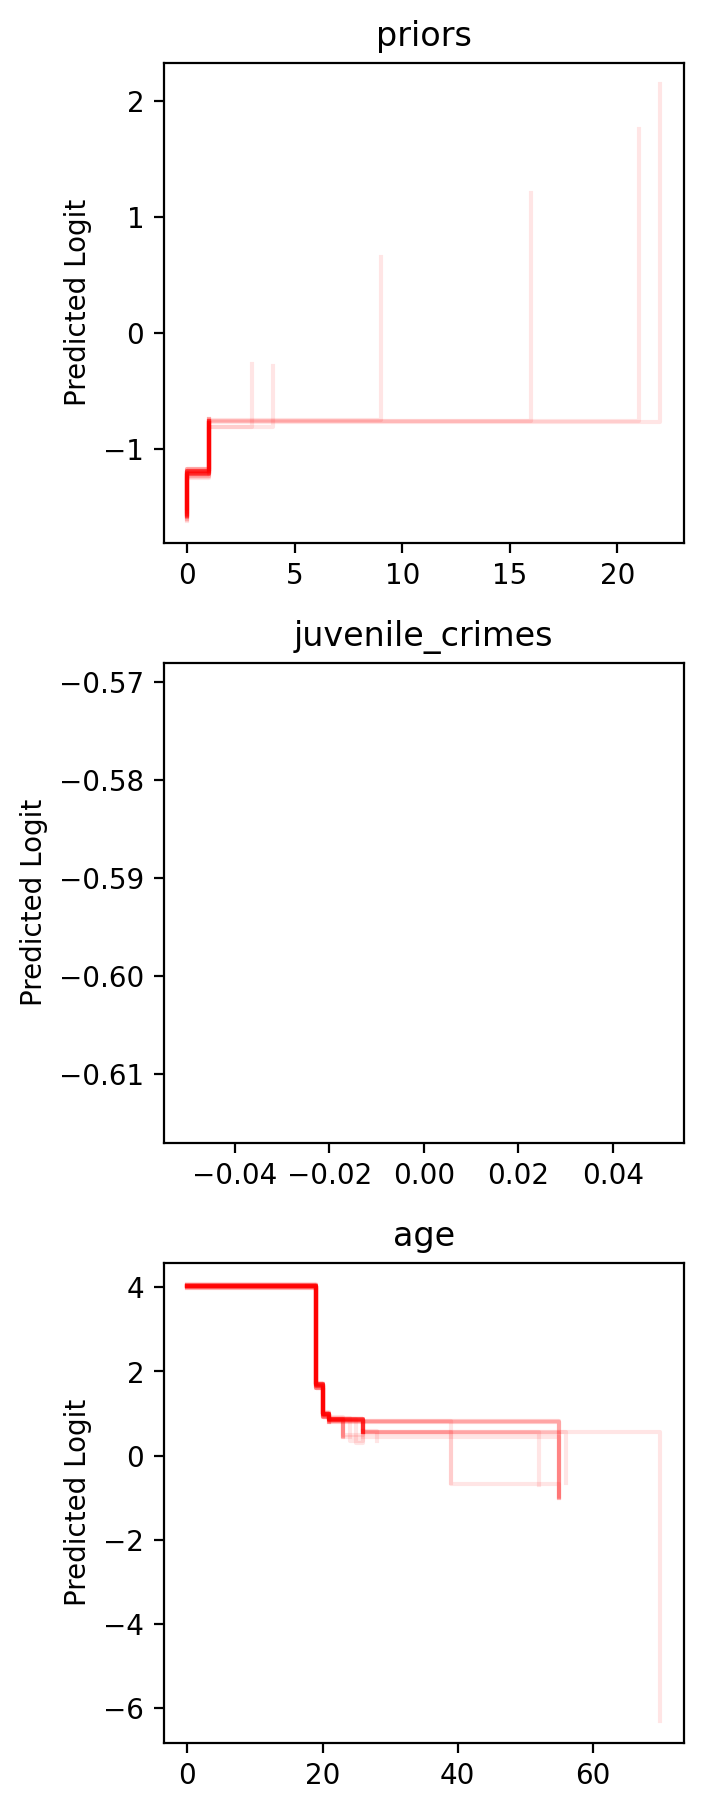

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import defaultdict
from tqdm import tqdm

# Input data
def get_feature_thresholds(weights, columns):
    # Extract features and thresholds
    feature_thresholds = {}
    for col, weight in zip(columns, weights):
        match = re.search(r'([a-zA-Z]+)', col)
        if match:
            feature = match.group(1)
            # threshold = col
            threshold = re.findall(r'[\d.]+', col)
            if feature == 'juv':
                feature = 'juv_misd_count'
            if feature == 'juvenile':
                feature = 'juvenile_crimes'
            if feature not in feature_thresholds:
                feature_thresholds[feature] = []
            # if feature == 'current':
            #     print(threshold,list(map(float, threshold)), weight)
            feature_thresholds[feature].append((list(map(float, threshold)), weight))

    return feature_thresholds

def plot_gam(X, X_one_hot, header, list_of_weights):
    # Create subplots
    num_features = X.shape[1]
    # fig, axes = plt.subplots(num_features-2, 1, figsize=(10, 3 * num_features), sharex=False)
    fig = plt.figure(figsize=(13, 3))
    fig.set_dpi(200)
    ax_dict = defaultdict(int)
    if num_features == 1:
        axes = [axes]  # Ensure axes is iterable for a single feature
    counter = 0
    union_of_support_sets = defaultdict(int)
    for i in tqdm(range(len(list_of_weights))):
        weights = list_of_weights[i, :]
        columns = header[np.nonzero(weights)[0]]
        weights = weights[np.nonzero(weights)[0]]
        for column in columns:
            union_of_support_sets[column] += 1

        feature_thresholds = get_feature_thresholds(weights, columns)
        for feature, thresholds_weights in feature_thresholds.items():
            if feature == 'sex' or feature == 'current':
                continue
            if feature not in ax_dict:
                ax = fig.add_axes([0.05, 0.1+counter, 0.2, 0.8])
                ax_dict[feature] = ax
                counter += 1
            else:
                ax = ax_dict[feature]
            thresholds, feature_weights = zip(*thresholds_weights)

            x = range(len(thresholds))  # X-axis positions for thresholds
            x_vals, y_vals = [], []
            x_vals.append(0)
            y_vals.append(feature_weights[0])
            flag = False
            for i in range(len(thresholds) - 1):
                x_vals.append(thresholds[i][0])
                y_vals.append(feature_weights[i])
            if flag:
                continue

            # For the last value of the interval, add it once more
            x_vals.append(thresholds[-1][0])
            y_vals.append(feature_weights[-1])

            ax.step(x_vals, y_vals, where="post", color='r', alpha=0.1)
            ax.set_ylabel("Predicted Logit")
            ax.set_title(feature)
    plt.tight_layout()
    plt.show()
    return union_of_support_sets

union_of_support_sets = plot_gam(X, X_one_hot, header, betas[:100, :])

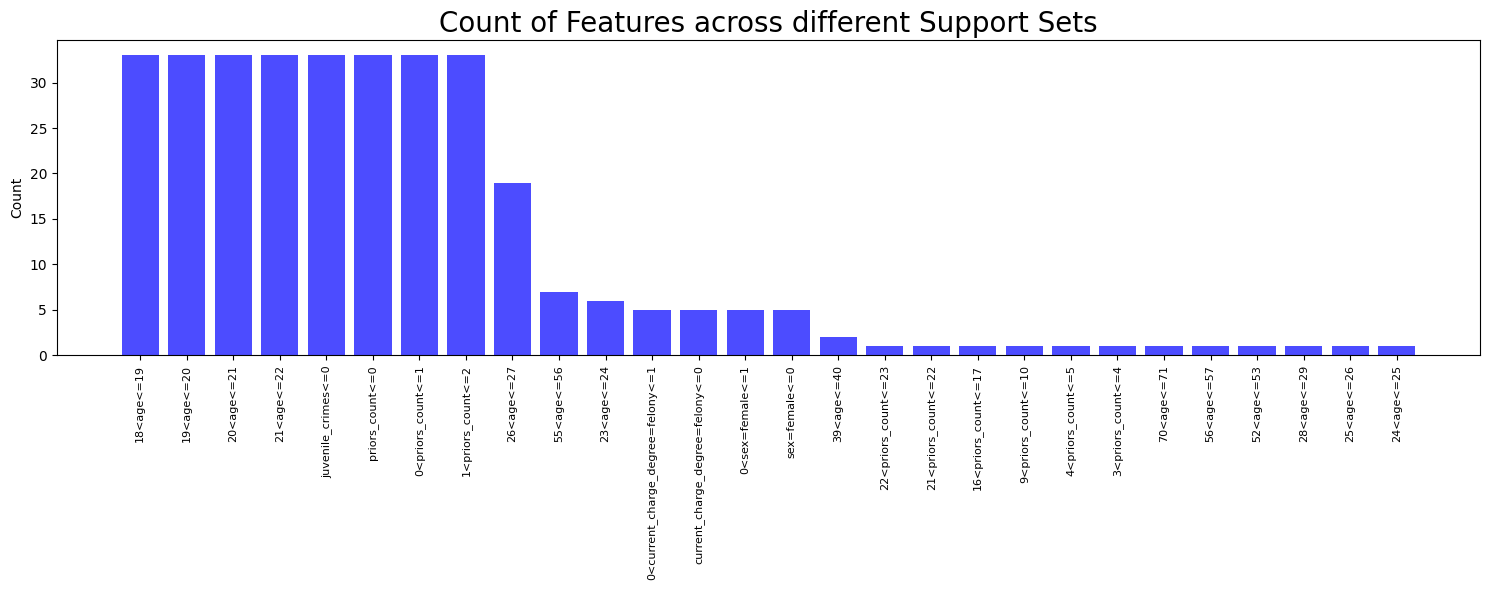

In [9]:
# Given dictionary
sorted_data = dict(sorted(union_of_support_sets.items(), key=lambda x: x[1], reverse=True))

# Prepare data for histogram
keys = list(sorted_data.keys())
values = list(sorted_data.values())

# Plot histogram
plt.figure(figsize=(15, 6))
plt.bar(keys, values, color='blue', alpha=0.7)
plt.xticks(rotation=90, fontsize=8)
plt.ylabel('Count')
plt.title('Count of Features across different Support Sets', fontsize=20)
plt.tight_layout()
plt.show()

In [10]:
header = pkl.load(open(betas_fastSparse, 'rb'))['header_new']
header = [i.replace('.0', '') for i in header]
print(keys)
print(header)
# for key in keys[:15]:
#     print(header,key)
# if key in header:
#     print(key)

['18<age<=19', '19<age<=20', '20<age<=21', '21<age<=22', 'juvenile_crimes<=0', 'priors_count<=0', '0<priors_count<=1', '1<priors_count<=2', '26<age<=27', '55<age<=56', '23<age<=24', '0<current_charge_degree=felony<=1', 'current_charge_degree=felony<=0', '0<sex=female<=1', 'sex=female<=0', '39<age<=40', '22<priors_count<=23', '21<priors_count<=22', '16<priors_count<=17', '9<priors_count<=10', '4<priors_count<=5', '3<priors_count<=4', '70<age<=71', '56<age<=57', '52<age<=53', '28<age<=29', '25<age<=26', '24<age<=25']
['intercept', 'age<=22', '22<age<=27', '27<age<=32', '32<age<=33', '33<age<=36', '36<age<=96', 'juvenile_crimes<=0', '0<juvenile_crimes<=20', 'priors_count<=0', '0<priors_count<=1', '1<priors_count<=2', '2<priors_count<=3', '3<priors_count<=4', '4<priors_count<=5', '5<priors_count<=6', '6<priors_count<=7', '7<priors_count<=38']
